In [1]:
from src.models import DinoVLM
import torch
from icecream import ic
import json
from transformers import pipeline
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, TaskType
from src.dataset_utils import *
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import os
from tqdm.notebook import tqdm

Failed to load /home/system/miniconda3/envs/gemma/lib/python3.10/site-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /home/system/miniconda3/envs/gemma/lib/python3.10/site-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /home/system/miniconda3/envs/gemma/lib/python3.10/site-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /home/system/miniconda3/envs/gemma/lib/python3.10/site-packages/torchao/_C_cutlass_90a.abi3.so


In [2]:
import torch
from peft import PeftModel, LoraConfig
from transformers import AutoProcessor
from src.models import DinoVLM # your class

model = DinoVLM(dino_dim=384, gemma_dim=2304)
model.freeze_vision()  # match training state

lora_config = LoraConfig(
    r=32,
    lora_alpha=128,
    target_modules=r"language_model\.layers\.\d+\.self_attn\.(q|k|v)_proj",
    lora_dropout=0.05,
    bias="none",
)
model = get_peft_model(model, lora_config)


checkpoint_dir = "/media/system/ZERBUIS_EXT_STOR/temp/exp/experiment/depth_tuning/experiments_gemma/checkpoints_1780127094.7091677/stage2/best"

# This loads adapter_model.safetensors into the LoRA layers AND connector
model.load_adapter(checkpoint_dir, adapter_name="default")

model = model.merge_and_unload()

model.eval().to("cuda")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using cache found in /home/system/.cache/torch/hub/ywyue_FiT3D_main
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


[INFO] Freezed ViT


DinoVLM(
  (vision_encoder): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='

In [3]:
from PIL import Image
image = Image.open("/media/system/ZERBUIS_EXT_STOR/temp/exp/experiment/depth_tuning/left.jpg")
image = image.resize((384, 384))

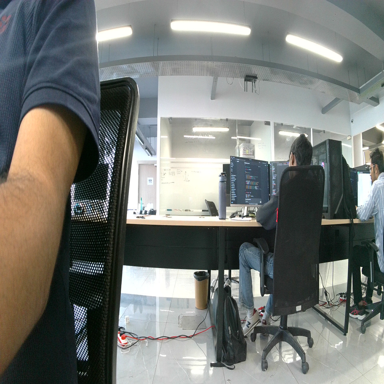

In [13]:
image

In [20]:
prompt = ('Do you see any mounitors in the image yes/no?')


In [21]:
with torch.no_grad():
    raw_response = model.generate_output(
        images=[image],
        prompts=[prompt],
        max_new_tokens=100,
    )[0]


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


EOS hit, stopping


In [22]:
raw_response

'832300300300 of 830003000000300003000 is 1000 Graffiti'

In [8]:
import warnings
import torch
from PIL import Image
from peft import LoraConfig, get_peft_model
from src.models import SigLipVLM

# ── Load model ────────────────────────────────────────────────────
CKPT = "/media/system/ZERBUIS_EXT_STOR/temp/exp/experiment/depth_tuning/experiments_gemma/checkpoints_1780482936.8283668/stage2/best"

model = SigLipVLM()
model.freeze_vision()
model.freeze_lm()

lora_config = LoraConfig(
    r=32, lora_alpha=128,
    target_modules=r"language_model\.layers\.\d+\.self_attn\.(q|k|v)_proj",
    lora_dropout=0.05, bias="none",
)
model = get_peft_model(model, lora_config)
model.load_adapter(CKPT, adapter_name="default")
model.eval().to("cuda")
print("Model loaded!")

# ── Inference ─────────────────────────────────────────────────────
def ask(image_path, question):
    image = Image.open(image_path).convert("RGB").resize((384, 384))
    
    # fix 1: match training prompt format exactly
    prompt = f"answer en {question}\n"
    
    with torch.no_grad():
        answer = model.generate_output(
            images=[image],
            prompts=[prompt],
            max_new_tokens=200,
            do_sample=False,
            repetition_penalty=1.3,   # fix 2: kills repetition loops
            eos_token_id=model.processor.tokenizer.eos_token_id,  # fix 3: explicit eos
        )[0]
    
    print(f"Q: {question}")
    print(f"A: {answer}")

# ── Usage ─────────────────────────────────────────────────────────

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[INFO] Freezed ViT
[INFO] Freezed LM
Model loaded!


In [11]:
ask("/media/system/ZERBUIS_EXT_STOR/temp/exp/experiment/depth_tuning/left.jpg", "What is the scene? is it a bedroom?")


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


EOS hit, stopping
Q: What is the scene? is it a bedroom?
A: 
